## **One Hot Encoding dan Clustering**


---

Anggota :
- Yovie Pradea Sandiana (217006081)
- Muhamad Bayu Setiawan (217006083)

# Persoalan Bisnis

1. Supervisor memberikan Anda data-data pelanggan yang bisa diakses pada LINK berikut. Anda diminta untuk:

    a. Membuat segmentasi atau cluster pelanggan

        i. Pastikan kolom Dt_Customer diubah menjadi kolom Years_Since_Registration (Menunjukkan jumlah tahun pelanggan sejak mendaftar sampai tahun sekarang)

        ii. Pastikan kolom Year_Birth diubah menjadi kolom Age (Menunjukkan usia pelanggan tahun sekarang)

    b. Informasikan karakteristik dari pelanggan pada masing-masing cluster tersebut. Anda dapat menamakan cluster tersebut sesuai dengan karakteristik pelanggan.

# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from time import time
from datetime import datetime
import seaborn as sns
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import statsmodels.api as sa
import statsmodels.formula.api as sm
%matplotlib inline

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Eksplorasi Data awal

## Import File Dataset

In [ ]:
# masukkan data dari file yang disiapkan ke sebuah dataframe
# disini saya menggunakan format csv
data_c = pd.read_csv('customer_data.csv')

In [ ]:
# cek data customer dengan mencoba menampilkan 10 baris pertama
data_c.head(10)

,ID,Year_Birth,Education,Income,Dt_Customer,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
0,5524,1957,Graduation,58138.0,9/4/2012,58,8,4,7
1,2174,1954,Graduation,46344.0,3/8/2014,38,1,2,5
2,4141,1965,Graduation,71613.0,8/21/2013,26,8,10,4
3,6182,1984,Graduation,26646.0,2/10/2014,26,2,4,6
4,5324,1981,PhD,58293.0,1/19/2014,94,5,6,5
5,7446,1967,Master,62513.0,9/9/2013,16,6,10,6
6,965,1971,Graduation,55635.0,11/13/2012,34,7,7,6
7,6177,1985,PhD,33454.0,5/8/2013,32,4,4,8
8,4855,1974,PhD,30351.0,6/6/2013,19,3,2,9
9,5899,1950,PhD,5648.0,3/13/2014,68,1,0,20


In [ ]:
# cek juga jumlah baris data untuk mengetahui seberapa banyak data yang ada
data_c.shape[0]

2240

# Pengecekan missing value

In [ ]:
# lihat informasi dari data kita
data_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 2240 non-null   int64  
 1   Year_Birth         2240 non-null   int64  
 2   Education          2240 non-null   object 
 3   Income             2216 non-null   float64
 4   Dt_Customer        2240 non-null   object 
 5   Recency            2240 non-null   int64  
 6   NumWebPurchases    2240 non-null   int64  
 7   NumStorePurchases  2240 non-null   int64  
 8   NumWebVisitsMonth  2240 non-null   int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 157.6+ KB


In [ ]:
# Mengubah tipe data kolom Dt_Customer menjadi tipe data tanggal (datetime)
data_c['Dt_Customer'] = pd.to_datetime(data_c['Dt_Customer'])

In [ ]:
# hitung jumlah missing value di tiap kolom
data_c.isna().sum()

ID                    0
Year_Birth            0
Education             0
Income               24
Dt_Customer           0
Recency               0
NumWebPurchases       0
NumStorePurchases     0
NumWebVisitsMonth     0
dtype: int64

In [ ]:
# hitung proporsi missing value di tiap kolom
(data_c.isna().sum() / data_c.shape[0]) * 100

ID                   0.000000
Year_Birth           0.000000
Education            0.000000
Income               1.071429
Dt_Customer          0.000000
Recency              0.000000
NumWebPurchases      0.000000
NumStorePurchases    0.000000
NumWebVisitsMonth    0.000000
dtype: float64

Karena terdapat missing value, maka akan dilakukan proses lanjutan yaitu imputasi data

# Data Cleaning

## Pengecekan duplikat

In [ ]:
# cek ada berapa jumlah data yang duplikat
data_c.duplicated().sum()

0

Karena tidak ada duplikasi data customer, maka proses pengecekan duplikasi data customer selesai

## Imputasi Missing Value

In [ ]:
# hitung proporsi missing value di tiap kolom
(data_c.isna().sum() / data_c.shape[0]) * 100

ID                   0.000000
Year_Birth           0.000000
Education            0.000000
Income               1.071429
Dt_Customer          0.000000
Recency              0.000000
NumWebPurchases      0.000000
NumStorePurchases    0.000000
NumWebVisitsMonth    0.000000
dtype: float64

In [ ]:
# filter dataframe untuk menampilkan baris yang nilainya null di salah satu kolom
data_c[data_c['Income'].isna()]

,ID,Year_Birth,Education,Income,Dt_Customer,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
10,1994,1983,Graduation,NaN,2013-11-15,11,1,2,7
27,5255,1986,Graduation,NaN,2013-02-20,19,27,0,1
43,7281,1959,PhD,NaN,2013-11-05,80,1,4,2
48,7244,1951,Graduation,NaN,2014-01-01,96,2,4,6
58,8557,1982,Graduation,NaN,2013-06-17,57,2,3,6
71,10629,1973,2n Cycle,NaN,2012-09-14,25,3,3,8
90,8996,1957,PhD,NaN,2012-11-19,4,7,8,9
91,9235,1957,Graduation,NaN,2014-05-27,45,1,2,7
92,5798,1973,Master,NaN,2013-11-23,87,2,8,1
128,8268,1961,PhD,NaN,2013-07-11,23,6,7,6


In [ ]:
# filter dataframe untuk menampilkan baris yang nilainya null di salah satu kolom
data_c[data_c['Income'].isna()].shape[0]

24

Karena yang terdapat missing value adalah kolom Income/Pendapatan, maka saya asumsikan bahwa para user yang Income nya null, saat registrasi tidak mengisi data Income karena pada saat itu belum mendapatkan pekerjaan, sehingga isi missing value tersebut dengan 0

In [ ]:
# Pilih kolom dan isi missing value dengan 0
data_c["Income"] = data_c["Income"].fillna(0)

In [ ]:
# hitung proporsi missing value di tiap kolom
# dapat terlihat bahwa kolom nama sudah tidak memiliki data kosong
(data_c.isna().sum() / data_c.shape[0]) * 100

ID                   0.0
Year_Birth           0.0
Education            0.0
Income               0.0
Dt_Customer          0.0
Recency              0.0
NumWebPurchases      0.0
NumStorePurchases    0.0
NumWebVisitsMonth    0.0
dtype: float64

## Pengecekan typo

In [ ]:
# mari kita lihat isi dari kolom Education
# pada kolom Education tidak memiliki typo, sehingga tidak memerlukan proses lanjutan
data_c['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [ ]:
# Perulangan untuk memeriksa setiap kolom
for col in data_c.columns:
    if data_c[col].dtype in [int, float]:
        if (data_c[col] < 0).any():
            print(f"Ada nilai negatif dalam kolom {col}.")
        else:
            print(f"Tidak ada nilai negatif dalam kolom {col}.")

Tidak ada nilai negatif dalam kolom ID.
Tidak ada nilai negatif dalam kolom Year_Birth.
Tidak ada nilai negatif dalam kolom Income.
Tidak ada nilai negatif dalam kolom Recency.
Tidak ada nilai negatif dalam kolom NumWebPurchases.
Tidak ada nilai negatif dalam kolom NumStorePurchases.
Tidak ada nilai negatif dalam kolom NumWebVisitsMonth.


Dapat dilihat bahwa tidak ada typo, juga tidak ada nilai negatif yang bisa saja mengindikasikan nilai yang typo

# Persiapan Data

Karena pada persoalan bisnis diminta merubah kolom Year_Birth menjadi Age, dan Dt_Customer menjadi Years_Since_Registration, maka proses perubahan dilakukan dengan cara berikut.

In [ ]:
# Hitung selisih tahun antara tahun saat ini dan tahun lahir
data_c['Year_Birth'] = datetime.now().year - data_c['Year_Birth']
# Mengubah nama kolom 'year_birth' menjadi 'age'
data_c = data_c.rename(columns={'Year_Birth': 'Age'})
data_c.head(5)

,ID,Age,Education,Income,Dt_Customer,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
0,5524,66,Graduation,58138.0,2012-09-04,58,8,4,7
1,2174,69,Graduation,46344.0,2014-03-08,38,1,2,5
2,4141,58,Graduation,71613.0,2013-08-21,26,8,10,4
3,6182,39,Graduation,26646.0,2014-02-10,26,2,4,6
4,5324,42,PhD,58293.0,2014-01-19,94,5,6,5


In [ ]:
# Hitung selisih tahun antara tahun saat ini dan tahun registrasi
data_c['Dt_Customer'] = datetime.now().year - data_c['Dt_Customer'].dt.year
# Mengubah nama kolom 'Dt_Customer' menjadi 'Years_Since_Registration'
data_c = data_c.rename(columns={'Dt_Customer': 'Years_Since_Registration'})
data_c.head(5)

,ID,Age,Education,Income,Years_Since_Registration,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
0,5524,66,Graduation,58138.0,11,58,8,4,7
1,2174,69,Graduation,46344.0,9,38,1,2,5
2,4141,58,Graduation,71613.0,10,26,8,10,4
3,6182,39,Graduation,26646.0,9,26,2,4,6
4,5324,42,PhD,58293.0,9,94,5,6,5


In [ ]:
# cek info data_c
data_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2229 entries, 0 to 2228
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        2229 non-null   int64  
 1   Age                       2229 non-null   int64  
 2   Education                 2229 non-null   object 
 3   Income                    2229 non-null   float64
 4   Years_Since_Registration  2229 non-null   int64  
 5   Recency                   2229 non-null   int64  
 6   NumWebPurchases           2229 non-null   int64  
 7   NumStorePurchases         2229 non-null   int64  
 8   NumWebVisitsMonth         2229 non-null   int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 156.9+ KB


kemudian merubah tipe data pada kolom ID menjadi object karena kolom tersebut berisikan nilai yang unik antara satu sama lain dengan syntax berikut.

In [ ]:
# Instruksi looping untuk mengubah tipe data pada kolom yang berakhiran dengan 'ID' menggunakan function astype()
for feature in data_c.columns:
    if feature.endswith("ID"):
        data_c[feature] = data_c[feature].astype("object")

In [ ]:
# cek kembali apakah proses mengubah tipe data sudah berhasil
data_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2229 entries, 0 to 2228
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        2229 non-null   object 
 1   Age                       2229 non-null   int64  
 2   Education                 2229 non-null   object 
 3   Income                    2229 non-null   float64
 4   Years_Since_Registration  2229 non-null   int64  
 5   Recency                   2229 non-null   int64  
 6   NumWebPurchases           2229 non-null   int64  
 7   NumStorePurchases         2229 non-null   int64  
 8   NumWebVisitsMonth         2229 non-null   int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 156.9+ KB


# Mengatasi outlier

Kita akan gunakan metoda IQR untuk cek nilai outlier di data kita.

In [ ]:
# Perulangan untuk memeriksa setiap kolom
for col in data_c.columns:
    if data_c[col].dtype in [int, float]:
        print(f"Nilai tertinggi dalam kolom {col} = {data_c[col].max()}.")
        print(f"Nilai terendah dalam kolom {col} = {data_c[col].min()}.")

Nilai tertinggi dalam kolom ID = 11191.
Nilai terendah dalam kolom ID = 0.
Nilai tertinggi dalam kolom Age = 130.
Nilai terendah dalam kolom Age = 27.
Nilai tertinggi dalam kolom Income = 666666.0.
Nilai terendah dalam kolom Income = 0.0.
Nilai tertinggi dalam kolom Years_Since_Registration = 11.
Nilai terendah dalam kolom Years_Since_Registration = 9.
Nilai tertinggi dalam kolom Recency = 99.
Nilai terendah dalam kolom Recency = 0.
Nilai tertinggi dalam kolom NumWebPurchases = 27.
Nilai terendah dalam kolom NumWebPurchases = 0.
Nilai tertinggi dalam kolom NumStorePurchases = 13.
Nilai terendah dalam kolom NumStorePurchases = 0.
Nilai tertinggi dalam kolom NumWebVisitsMonth = 20.
Nilai terendah dalam kolom NumWebVisitsMonth = 0.


saya asumsikan bahwa kolom Age dan Income pada data customer memiliki outlier, karena nilai maksimal nya yang terlampau jauh dari rata rata nilai di kolom tersebut, sehingga perlu penanganan lebih lanjut.

<Axes: >

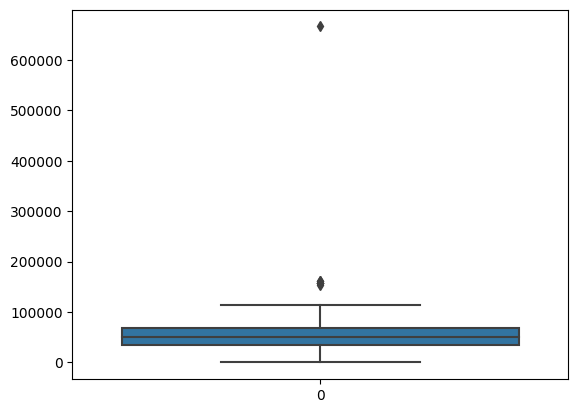

In [ ]:
# dapat dilihat bahwa Income memiliki nilai data yang outliernya tinggi
sns.boxplot(data_c['Income'])

<Axes: >

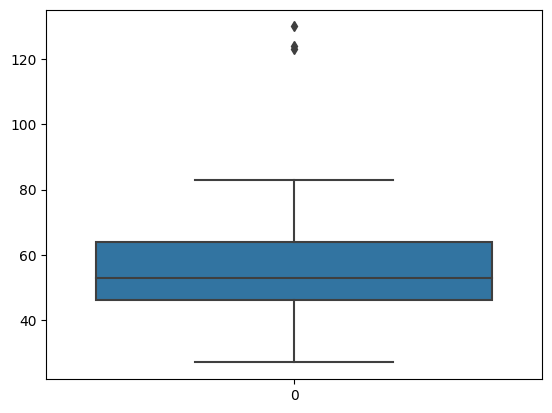

In [ ]:
# dapat dilihat bahwa Age memiliki nilai data yang outliernya cukup tinggi
sns.boxplot(data_c['Age'])

In [ ]:
# membuat fungsi cek outlier
def cek_outlier(nama_kolom, batas):
  Q1 = np.percentile(data_c[nama_kolom], 25,
                     interpolation = 'midpoint')

  Q3 = np.percentile(data_c[nama_kolom], 75,
                     interpolation = 'midpoint')

  IQR = Q3 - Q1

  if batas == 'upper_bound':
      bound = data_c[data_c[nama_kolom] >= (Q3 + 1.5*IQR)]
  elif batas == 'lower_bound':
      bound = data_c[data_c[nama_kolom] <= (Q1 - 1.5*IQR)]
  return bound

In [ ]:
# membuat fungsi cek batas
def cek_batas(nama_kolom, batas):
  Q1 = np.percentile(data_c[nama_kolom], 25,
                     interpolation = 'midpoint')

  Q3 = np.percentile(data_c[nama_kolom], 75,
                     interpolation = 'midpoint')

  IQR = Q3 - Q1

  if batas == 'upper_bound':
      bound = Q3 + 1.5*IQR
  elif batas == 'lower_bound':
      bound = Q1 - 1.5*IQR
  return bound

In [ ]:
# cek batas atas dan batas bawah setiap kolom yang ingin kita hapus outliernya
batasatas_income = cek_batas('Income', 'upper_bound')
batasbawah_income = cek_batas('Income', 'lower_bound')
batasatas_age = cek_batas('Age', 'upper_bound')
batasbawah_age = cek_batas('Age', 'lower_bound')
print(f"Batas atas outlier income adalah : {batasatas_income}")
print(f"Batas bawah outlier income adalah : {batasbawah_income}")
print(f"Batas atas outlier age adalah : {batasatas_age}")
print(f"Batas bawah outlier age adalah : {batasbawah_age}")

Batas atas outlier income adalah : 118672.25
Batas bawah outlier income adalah : -15657.75
Batas atas outlier age adalah : 91.0
Batas bawah outlier age adalah : 19.0


In [ ]:
# jalankan fungsi untuk cek total data outlier pada tiap kolom
upper_income = cek_outlier('Income', 'upper_bound').index.tolist()
lower_income = cek_outlier('Income', 'lower_bound').index.tolist()
upper_age = cek_outlier('Age', 'upper_bound').index.tolist()
lower_age = cek_outlier('Age', 'lower_bound').index.tolist()
print(f"Jumlah total outlier di kolom Income : {len(upper_income)}")
print(f"Jumlah total outlier di kolom Age : {len(upper_age) + len(lower_age)}")

Jumlah total outlier di kolom Income : 8
Jumlah total outlier di kolom Age : 3


In [ ]:
# berikut merupakan data yang akan kita hapus pada kolom Income
data_c.loc[data_c.index.isin(upper_income) | data_c.index.isin(lower_income)]

,ID,Age,Education,Income,Years_Since_Registration,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
164,8475,50,PhD,157243.0,9,98,0,0,0
617,1503,47,PhD,162397.0,10,31,0,1,1
655,5555,48,Graduation,153924.0,9,81,0,0,0
687,1501,41,PhD,160803.0,11,21,0,1,0
1300,5336,52,Master,157733.0,10,37,1,1,1
1653,4931,46,Graduation,157146.0,10,13,0,0,1
2132,11181,74,PhD,156924.0,10,85,0,0,0
2233,9432,46,Graduation,666666.0,10,23,3,3,6


In [ ]:
# berikut merupakan data yang akan kita hapus pada kolom Age
data_c.loc[data_c.index.isin(upper_age) | data_c.index.isin(lower_age)]

,ID,Age,Education,Income,Years_Since_Registration,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
192,7829,123,2n Cycle,36640.0,10,99,2,2,5
239,11004,130,2n Cycle,60182.0,9,23,1,2,4
339,1150,124,PhD,83532.0,10,36,4,4,1


In [ ]:
# mari kita buat sebuah fungsi yang dapat menerima input sebuah data frame
# dan juga nama kolom untuk filter / menghapus data outlier
def filter_outlier(df, nama_kolom):
    if nama_kolom == 'Income':
        data_temp = df.loc[~df.index.isin(upper_income)]
        data_temp = data_temp.loc[~data_temp.index.isin(lower_income)]
        return data_temp
    if nama_kolom == 'Age':
        data_temp = df.loc[~df.index.isin(upper_age)]
        data_temp = data_temp.loc[~data_temp.index.isin(lower_age)]
        return data_temp


In [ ]:
# berikut merupakan total data sebelum outliernya dihapus
print(f"total data customer sebelum outlier dihapus {data_c.shape[0]}")

# timpa dataframe data_c dengan memanggil fungsi filter_outlier untuk menghapus outlier
data_c = filter_outlier(data_c, 'Income')
data_c = filter_outlier(data_c, 'Age')

# berikut merupakan total data setelah outlier dihapus
print(f"total data customer sesudah outlier dihapus {data_c.shape[0]}")

total data customer sebelum outlier dihapus 2240
total data customer sesudah outlier dihapus 2229


<Axes: >

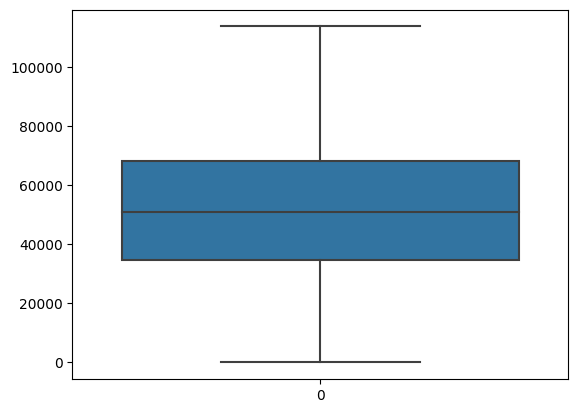

In [ ]:
# berikut merupakan boxplot Income setelah outlier dihapus
sns.boxplot(data_c['Income'])

<Axes: >

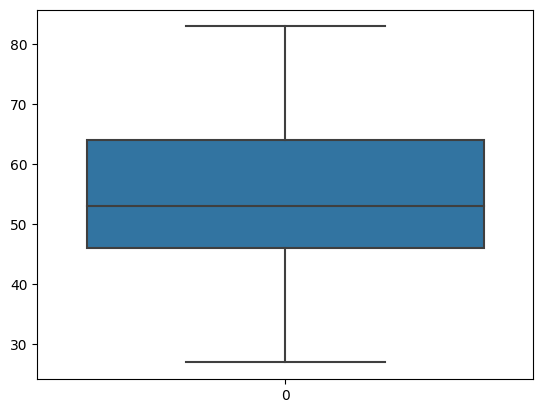

In [ ]:
# berikut merupakan boxplot Age setelah outlier dihapus
sns.boxplot(data_c['Age'])

In [ ]:
# final data, reset index untuk memperbarui nomor index
data_c = data_c.reset_index(drop=True)
data_c

,ID,Age,Education,Income,Years_Since_Registration,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
0,5524,66,Graduation,58138.0,11,58,8,4,7
1,2174,69,Graduation,46344.0,9,38,1,2,5
2,4141,58,Graduation,71613.0,10,26,8,10,4
3,6182,39,Graduation,26646.0,9,26,2,4,6
4,5324,42,PhD,58293.0,9,94,5,6,5
...,...,...,...,...,...,...,...,...,...
2224,10870,56,Graduation,61223.0,10,46,9,4,5
2225,4001,77,PhD,64014.0,9,56,8,5,7
2226,7270,42,Graduation,56981.0,9,91,2,13,6
2227,8235,67,Master,69245.0,9,8,6,10,3


In [ ]:
# terlihat bahwa nilai tertinggi dalam kolom Age dan Income sudah tidak melebihi batas atas dari outlier
for col in data_c.columns:
    if data_c[col].dtype in [int, float]:
        print(f"Nilai tertinggi dalam kolom {col} = {data_c[col].max()}.")
        print(f"Nilai terendah dalam kolom {col} = {data_c[col].min()}.")

Nilai tertinggi dalam kolom ID = 11191.
Nilai terendah dalam kolom ID = 0.
Nilai tertinggi dalam kolom Age = 83.
Nilai terendah dalam kolom Age = 27.
Nilai tertinggi dalam kolom Income = 113734.0.
Nilai terendah dalam kolom Income = 0.0.
Nilai tertinggi dalam kolom Years_Since_Registration = 11.
Nilai terendah dalam kolom Years_Since_Registration = 9.
Nilai tertinggi dalam kolom Recency = 99.
Nilai terendah dalam kolom Recency = 0.
Nilai tertinggi dalam kolom NumWebPurchases = 27.
Nilai terendah dalam kolom NumWebPurchases = 0.
Nilai tertinggi dalam kolom NumStorePurchases = 13.
Nilai terendah dalam kolom NumStorePurchases = 0.
Nilai tertinggi dalam kolom NumWebVisitsMonth = 20.
Nilai terendah dalam kolom NumWebVisitsMonth = 0.


kolom Dt_Customer dan Year_Birth sudah diubah sesuai ketentuan pada saat sebelum dilakukannya proses mengatasi outlier, sehingga proses selanjutnya yaitu membuat segmentasi atau cluster pelanggan

# Proses Analisis

karena kolom ID berisikan nilai yang unik, maka kolom tersebut tidak akan dipakai pada proses clustering, sehingga akan dilakukan proses penghapusan/drop kolom ID.

In [ ]:
# drop atau hapus data ID, karena pada proses clustering ini, ID tidak akan dipakai
X = data_c.drop('ID', axis=1)
X

,Age,Education,Income,Years_Since_Registration,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
0,66,Graduation,58138.0,11,58,8,4,7
1,69,Graduation,46344.0,9,38,1,2,5
2,58,Graduation,71613.0,10,26,8,10,4
3,39,Graduation,26646.0,9,26,2,4,6
4,42,PhD,58293.0,9,94,5,6,5
...,...,...,...,...,...,...,...,...
2224,56,Graduation,61223.0,10,46,9,4,5
2225,77,PhD,64014.0,9,56,8,5,7
2226,42,Graduation,56981.0,9,91,2,13,6
2227,67,Master,69245.0,9,8,6,10,3


In [ ]:
# terlihat bahwa data sudah tidak terdapat kolom ID
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2229 entries, 0 to 2228
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       2229 non-null   int64  
 1   Education                 2229 non-null   object 
 2   Income                    2229 non-null   float64
 3   Years_Since_Registration  2229 non-null   int64  
 4   Recency                   2229 non-null   int64  
 5   NumWebPurchases           2229 non-null   int64  
 6   NumStorePurchases         2229 non-null   int64  
 7   NumWebVisitsMonth         2229 non-null   int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 139.4+ KB


## Tahap One Hot Encoding

In [ ]:
# lakukan proses encoder dengan menggunakan One Hot Encoder untuk mengubah semua nilai menjadi nilai numerik
# sehingga proses clustering dapat dilakukan
encoder = OneHotEncoder()
encoder.fit(X.select_dtypes(include="object"))
X_onehot = pd.DataFrame(encoder.transform(X.select_dtypes(include="object")).toarray(),columns=encoder.get_feature_names_out())

X_preprocessed = pd.concat([X.select_dtypes(exclude="object"), X_onehot],axis=1)

scaler = StandardScaler()
scaler.fit(X_preprocessed)
X_scaled = pd.DataFrame(scaler.transform(X_preprocessed),columns=X_preprocessed.columns)

X_scaled.head()

,Age,Income,Years_Since_Registration,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,1.015715,0.332405,1.500215,0.307314,1.405471,-0.559160,0.689920,-0.314821,-0.157568,0.991512,-0.445407,-0.524568
1,1.272020,-0.221969,-1.420291,-0.383771,-1.117198,-1.176175,-0.138430,-0.314821,-0.157568,0.991512,-0.445407,-0.524568
2,0.332234,0.965793,0.039962,-0.798422,1.405471,1.291882,-0.552605,-0.314821,-0.157568,0.991512,-0.445407,-0.524568
3,-1.291031,-1.147868,-1.420291,-0.798422,-0.756817,-0.559160,0.275745,-0.314821,-0.157568,0.991512,-0.445407,-0.524568
4,-1.034726,0.339690,-1.420291,1.551268,0.324327,0.057854,-0.138430,-0.314821,-0.157568,-1.008561,-0.445407,1.906330


## Tahap Clustering

tahap selanjutnya yaitu mencoba membuat clustering menggunakan kmeans dengan nilai k yang berbeda beda, yaitu 5, 15, dan juga menggunakan Mini Batch KMeans dengan k = 15

In [ ]:
K = 5
kmeans_5 = KMeans(n_clusters=K, random_state=6)

start = time()
kmeans_5.fit(X_scaled)
print(f"Done fitting kMeans in {time()-start:.3f}s")

Done fitting kMeans in 1.026s


In [ ]:
K = 15
kmeans_15 = KMeans(n_clusters=K, random_state=6)

start = time()
kmeans_15.fit(X_scaled)
print(f"Done fitting kMeans in {time()-start:.3f}s")

Done fitting kMeans in 0.718s


In [ ]:
K = 15
mb_kmeans_15 = MiniBatchKMeans(n_clusters=K)

start = time()
mb_kmeans_15.fit(X_scaled)
print(f"Done fitting kMeans in {time()-start:.3f}s")

Done fitting kMeans in 0.153s


selanjutnya lakukan proses memasukkan nilai cluster yang tadi dibuat kedalam dataframe

In [ ]:
X = X.assign(
    clusters_of_5=kmeans_5.predict(X_scaled),
    clusters_of_15=kmeans_15.predict(X_scaled),
    clusters_of_15_mb=mb_kmeans_15.predict(X_scaled),
)

with pd.option_context("display.max_columns", None):
    display(X.head())

,Age,Education,Income,Years_Since_Registration,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,clusters_of_5,clusters_of_15,clusters_of_15_mb
0,66,Graduation,58138.0,11,58,8,4,7,0,1,13
1,69,Graduation,46344.0,9,38,1,2,5,4,9,12
2,58,Graduation,71613.0,10,26,8,10,4,0,12,13
3,39,Graduation,26646.0,9,26,2,4,6,4,9,6
4,42,PhD,58293.0,9,94,5,6,5,2,6,0


#### Cluster Cardinality

berikut merupakan tampilan dari tiap hasil clustering tadi

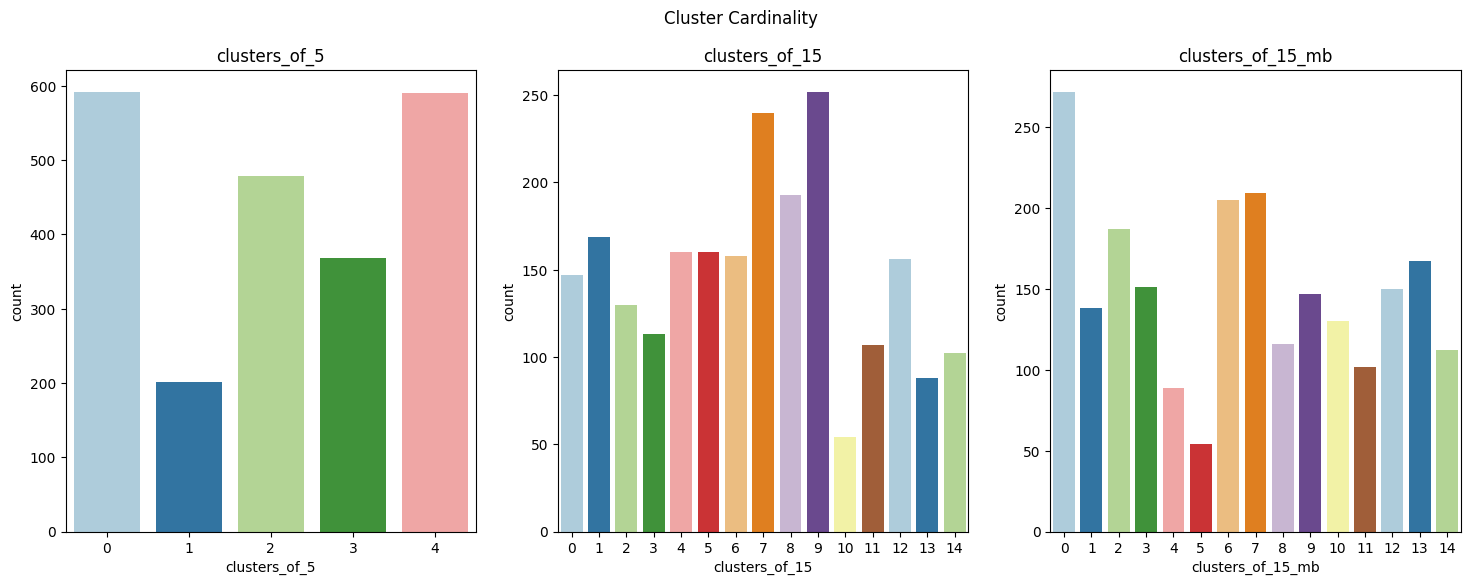

In [ ]:
fig, axis = plt.subplots(1, 3, figsize=(18, 6))
for ax, preds in zip(axis, ["clusters_of_5", "clusters_of_15", "clusters_of_15_mb"]):
    sns.countplot(x=preds, data=X, ax=ax, palette="Paired")
    ax.set_title(preds)
plt.suptitle("Cluster Cardinality")
plt.show()

#### Cluster Magnitude

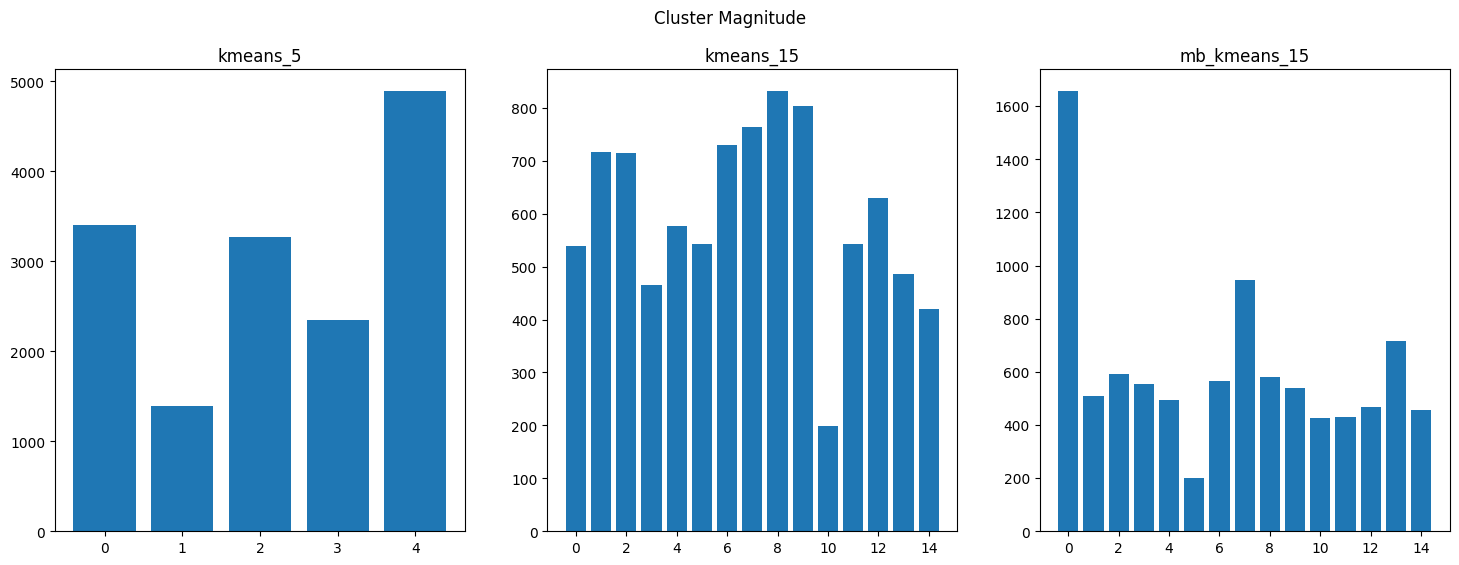

In [ ]:
fig, axis = plt.subplots(1, 3, figsize=(18, 6))
for ax, model, name in zip(axis,[kmeans_5, kmeans_15, mb_kmeans_15],["kmeans_5", "kmeans_15", "mb_kmeans_15"]):
    distances = model.transform(X_scaled)
    preds = model.predict(X_scaled)
    inertia_per_cluster = np.array([sum(dist[c]**2 for dist, c in zip(distances, preds) if c == cluster)
        for cluster in range(model.n_clusters)])
    ax.bar(x=range(model.n_clusters), height=inertia_per_cluster)
    ax.set_title(name)
plt.suptitle("Cluster Magnitude")
plt.show()

#### Elbow Method

untuk memastikan dan mendapatkan nilai k yang paling sesuai pada kasus clustering ini, maka dilakukan proses lanjutan memakai elbow method

In [ ]:
# sum of squared distances
ssd = []

# may take a longer time to run (takes up to approximately 6 min)
for k in range(1, 20):
    model = KMeans(n_clusters=k, random_state=6)
    print(f"Clustering with n_clusters={k}")
    start = time()
    model.fit(X_scaled)
    print(f"Done clustering in {time()-start:.3f}s")

    ssd.append(model.inertia_)

Clustering with n_clusters=1
Done clustering in 0.531s
Clustering with n_clusters=2
Done clustering in 1.934s
Clustering with n_clusters=3
Done clustering in 2.015s
Clustering with n_clusters=4
Done clustering in 1.228s
Clustering with n_clusters=5
Done clustering in 0.139s
Clustering with n_clusters=6
Done clustering in 0.542s
Clustering with n_clusters=7
Done clustering in 0.215s
Clustering with n_clusters=8
Done clustering in 0.429s
Clustering with n_clusters=9
Done clustering in 0.594s
Clustering with n_clusters=10
Done clustering in 0.409s
Clustering with n_clusters=11
Done clustering in 1.142s
Clustering with n_clusters=12
Done clustering in 0.471s
Clustering with n_clusters=13
Done clustering in 0.567s
Clustering with n_clusters=14
Done clustering in 1.569s
Clustering with n_clusters=15
Done clustering in 1.957s
Clustering with n_clusters=16
Done clustering in 1.094s
Clustering with n_clusters=17
Done clustering in 1.571s
Clustering with n_clusters=18
Done clustering in 4.033s
C

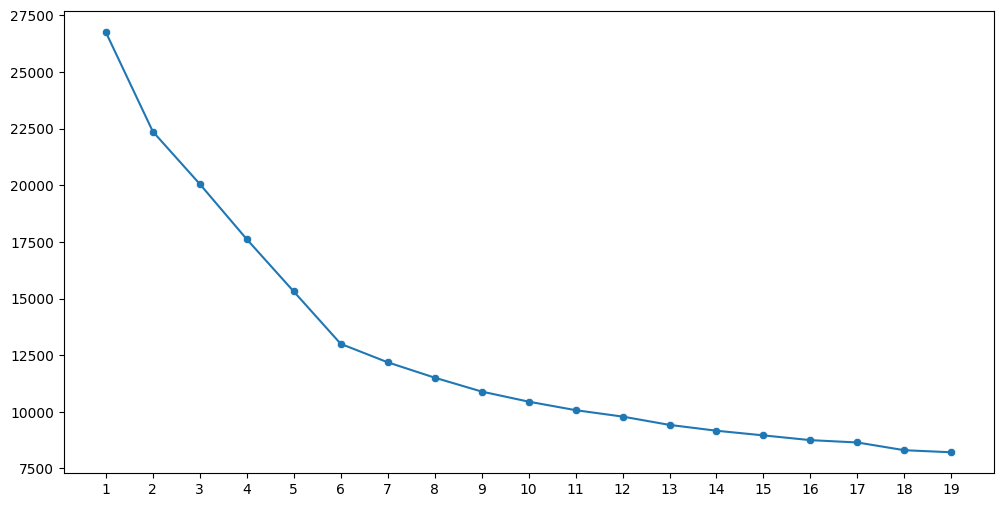

In [ ]:
# tampilkan hasil dari Elbow method
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(1, 20), y=ssd)
sns.scatterplot(x=range(1, 20), y=ssd)
plt.xticks(range(1, 20))
plt.show()

dilihat dari Elbow Method, maka nilai k = 6 merupakan nilai yang paling optimal untuk clustering pada data customer ini, tetapi agar lebih yakin, maka dapat dilakukan proses lanjutan yaitu menggunakan metode Silhouette Coefficient sebagai perbandingan

#### Silhouette Coefficient

In [ ]:
# Code for the whole dataset
silhouette_scores = []

# may take a longer time to run
for k in range(2, 21):
    model = KMeans(n_clusters=k, random_state=11)
    print(f"Clustering with n_clusters={k}")
    start = time()
    model.fit(X_scaled)
    print(f"Done clustering in {time()-start:.3f}s")

    print("Calculating silhouette coefficient..")
    start = time()
    silhouette_scores.append(silhouette_score(X_scaled, model.labels_))
    print(f"Done calculating in {time()-start:.3f}s")

Clustering with n_clusters=2
Done clustering in 0.162s
Calculating silhouette coefficient..
Done calculating in 0.154s
Clustering with n_clusters=3
Done clustering in 0.228s
Calculating silhouette coefficient..
Done calculating in 0.164s
Clustering with n_clusters=4
Done clustering in 0.161s
Calculating silhouette coefficient..
Done calculating in 0.191s
Clustering with n_clusters=5
Done clustering in 0.185s
Calculating silhouette coefficient..
Done calculating in 0.167s
Clustering with n_clusters=6
Done clustering in 0.350s
Calculating silhouette coefficient..
Done calculating in 0.164s
Clustering with n_clusters=7
Done clustering in 0.319s
Calculating silhouette coefficient..
Done calculating in 0.172s
Clustering with n_clusters=8
Done clustering in 1.172s
Calculating silhouette coefficient..
Done calculating in 0.231s
Clustering with n_clusters=9
Done clustering in 0.609s
Calculating silhouette coefficient..
Done calculating in 0.097s
Clustering with n_clusters=10
Done clustering in

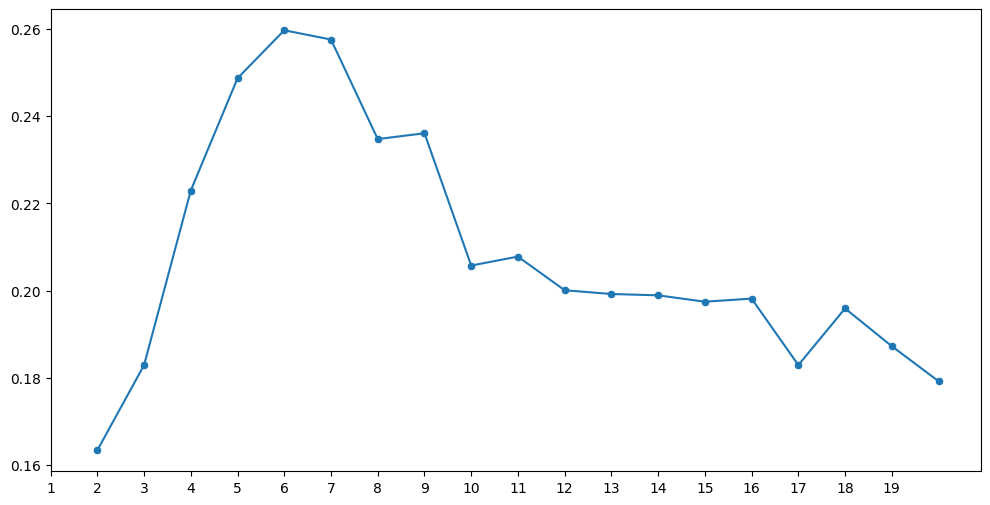

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(2, 21), y=silhouette_scores)
sns.scatterplot(x=range(2, 21), y=silhouette_scores)
plt.xticks(range(1, 20))
plt.show()

dapat terlihat bahwa nilai tertingginya yaitu ada di angka 6, sehingga benar bahwa cluster dengan k = 6 adalah nilai k yang paling optimal pada proses cluster ini, sehingga akan kita lanjutkan untuk membuat cluster dengan k = 6

In [ ]:
# hapus terlebih dahulu cluster yang sebelumnya sudah dibuat
X = X.drop(['clusters_of_5', 'clusters_of_15', 'clusters_of_15_mb'], axis=1)
X.head(3)

,Age,Education,Income,Years_Since_Registration,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
0,66,Graduation,58138.0,11,58,8,4,7
1,69,Graduation,46344.0,9,38,1,2,5
2,58,Graduation,71613.0,10,26,8,10,4


In [ ]:
# buat cluster baru dengan K = 6
K = 6
cluster = KMeans(n_clusters=K, random_state=11)

start = time()
cluster.fit(X_scaled)
print(f"Done fitting kMeans in {time()-start:.3f}s")

Done fitting kMeans in 0.255s


In [ ]:
# masukkan nilai cluster tersebut kedalam data customer
X = X.assign(
    Cluster=cluster.predict(X_scaled),
)

with pd.option_context("display.max_columns", None):
    display(X.head())

,Age,Education,Income,Years_Since_Registration,Recency,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Cluster
0,66,Graduation,58138.0,11,58,8,4,7,3
1,69,Graduation,46344.0,9,38,1,2,5,4
2,58,Graduation,71613.0,10,26,8,10,4,3
3,39,Graduation,26646.0,9,26,2,4,6,4
4,42,PhD,58293.0,9,94,5,6,5,5


In [ ]:
# lakukan proses lanjutan untuk menganalisis hasil dari clustering
cluster1 = X.pivot_table(index=['Cluster','Education'],
                         values=['Age','Income', 'Recency','Years_Since_Registration',
                                 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'],
                           aggfunc={'Age' : 'mean',
                                    'Years_Since_Registration' : 'mean',
                                    'Income': 'mean',
                                    'Recency': 'mean',
                                    'NumWebPurchases': 'mean',
                                    'NumStorePurchases': 'mean',
                                    'NumWebVisitsMonth': 'mean'}, sort = False)
cluster1 = cluster1.sort_values('Cluster').reset_index()
cluster1.columns = ['Cluster' , 'Edukasi', 'Rata rata Umur', 'Tahun ke Registrasi', 'Rata rata Penghasilan', 'Terakhir beli(hari)'
, 'Rata rata beli Online', 'Rata rata beli Offline', 'Rata rata cek website']
cluster1

,Cluster,Edukasi,Rata rata Umur,Tahun ke Registrasi,Rata rata Penghasilan,Terakhir beli(hari),Rata rata beli Online,Rata rata beli Offline,Rata rata cek website
0,0,Basic,45.537037,10.222222,20306.259259,48.444444,1.888889,2.851852,6.870370
1,1,2n Cycle,50.223881,10.024876,46914.507463,48.293532,3.751244,5.542289,5.462687
2,2,Master,56.173913,9.932065,52039.692935,47.739130,4.048913,5.923913,5.157609
3,3,Graduation,55.548161,9.980736,68751.332750,49.661996,5.716287,8.257443,3.877408
4,4,Graduation,51.146474,9.976492,33636.871609,50.481013,2.499096,3.349005,6.759494
5,4,PhD,66.333333,9.666667,5502.000000,57.666667,0.333333,0.333333,19.666667
6,4,Master,41.000000,10.000000,6560.000000,2.000000,1.000000,1.000000,17.000000
7,5,PhD,56.790795,9.941423,54955.002092,48.366109,4.487448,6.148536,5.219665


# Insight
Dapat dilihat bahwa cluster 0 merupakan kelompok dengan edukasi Basic yang memiliki karakteristik sudah sebulan terakhir ini jarang berbelanja, dengan angka pembelian yang rendah di web maupun store, tetapi memiliki rata rata cek website yang menengah ke rendah.

Cluster 1 merupakan kelompok user dengan background dari edukasi 2n Cycle dengan rata rata beli online, rata rata beli offline, dan rata rata cek website yang rendah.  juga merupakan user yang sudah jarang berbelanja, terlihat dari rata rata terakhir beli yang sudah cukup lama, yaitu mencapai 48 hari.

Selanjutnya cluster 2 yang berisi user dengan education Master, dengan karakteristik yang kurang lebih sama seperti cluster 1, yaitu rata rata beli online, rata rata beli offline, dan rata rata cek website yang rendah.  juga merupakan user yang sudah jarang berbelanja, terlihat dari rata rata terakhir beli yang sudah cukup lama, yaitu mencapai 48 hari.

Kemudian cluster 3 yang merupakan kumpulan user dengan edukasi Graduation, memiliki karakteristik yang lebih sering membeli barang secara offline, terlihat dengan rata rata beli online, dan rata rata cek website yang lebih sedikit dibandingkan dengan rata rata beli offline.

pada cluster 4 merupakan kumpulan dari beberapa user dengan background edukasi yang berbeda beda yaitu Graduation, PhD, dan Master, yang menjadi pembeda pada tiap jenis edukasi pada cluster ini dibanding dengan cluster lainnya yaitu :
- Graduation = memiliki rata rata penghasilan yang lebih sedikit dibanding dengan graduation pada cluster 3, juga karakteristik yang tidak terlalu suka berbelanja secara online maupun offline, tetapi memiliki rata rata cek website menengah ke rendah (beberapa kali cek website).
- PhD = memiliki rata rata penghasilan yang jauh lebih sedikit dibandingkan dengan PhD pada cluster 5 dengan perbandinga 5502 : 54955, perbedaan yang sangat jauh itu juga terjadi pada rata rata beli online maupun offline yang sangat kecil, tetapi disaat bersamaan sering melihat website.
- Master = memiliki rata rata usia yang cukup berbeda (lebih muda dari Master pada cluster 2), dan memiliki rata rata penghasilan yang jauh lebih kecil dari Master pada cluster 2, tetapi Master pada cluster 4 ini merupakan user yang baru aktif, terlihat dengan terakhir beli yang terpaut hanya 2 hari saja, tetapi rata rata beli online maupun offline yang rendah, dan memiliki rata rata cek website yang tinggi.

Terakhir yaitu cluster 5 yaitu berisi user dengan background PhD dengan karakteristik merupakan user yang sudah lama tidak berbelanja, memiliki minat belanja online maupun offline yang cukup rendah, juga tidak terlalu tertarik dengan website, terlihat dengan nilai rata rata cek website yang cukup rendah.